# Expert vs Predicted Affinity Confusion Matrix

This notebook compares expert labels against predicted labels for the same `(Abstract_Index, RA2025_ID)` pairs.

Metrics included:
1. Confusion matrix against expert labels
2. Per-class recall
3. Quadratic Weighted Kappa
4. Mean signed error
5. Reliability curve

- Expert source: `calibration_abstract_question_affinities.csv`
- Pred source: `adjudicated_ra_affinities.csv`

The expert `Expert_Affinity_Level` score is mapped to `Low` / `Moderate` / `High` using the same thresholds as the project adjudication code.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
import importlib
import sys

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

affinity_metrics = importlib.import_module("src.analysis.affinity_metrics")

expert_root = repo_root / "data" / "processed" / "affinity_calibration"
pred_root = repo_root / "data" / "results" / "affinity_benchmark"

# expert_run_dir_names = ["20260618_Mark_batch1_v4"] #calibration set
expert_run_dir_names = ["20260728_abstracts_evaluation_template_mark_om_v1"] # expert set
# expert_run_dir_names = ["20260728_abstracts_evaluation_template_charlie_s_v1"]  # expert set 
# pred_run_dir_names = ["20260721_124821_1"] 
# pred_run_dir_names = ["20260721_124821"]
# pred_run_dir_names = ["20260724_143127"]
# pred_run_dir_names = ["20260724_155639"] # 4 promts/calibration set
# pred_run_dir_names = ["20260726_134607_1"] # 4 promts/benchmark set
# pred_run_dir_names = ["20260726_134607_2"] # 4 promts/benchmark set
# pred_run_dir_names = ["20260726_154151_1"] # 20 promts/benchmark set
pred_run_dir_names = ["20260726_134607_5"] # 4 promts/benchmark set
# pred_run_dir_names = ["20260726_134607_6"]

expert_input_filename = "calibration_abstract_question_affinities.csv"
pred_input_filename = "adjudicated_ra_affinities.csv"

# Select "standard", "k3", "wide_low_3", "wide_low_2", or "six".
BAND_SCHEME = "standard"
BAND_SCHEMES = {
    "standard": {
        "band_count": 3,
        "labels": ["Low", "Moderate", "High"],
        "bins": [-np.inf, 40, 80, np.inf],
        "expert_column": "Evaluator_Affinity",
    },
    "k3": {
        "band_count": 3,
        "labels": ["Low|Low+", "Moderate", "Moderate+|High|High+"],
        "bins": [-np.inf, 40, 60, np.inf],
        "expert_column": "Evaluator_Affinity",
    },
    "wide_low_3": {
        "band_count": 3,
        "labels": ["Low", "Moderate", "High"],
        "bins": [-np.inf, 60, 80, np.inf],
        "expert_column": "Evaluator_Affinity",
    },
    "wide_low_2": {
            "band_count": 2,
            "labels": ["Not_Relevant", "Relevant"],
            "bins": [-np.inf, 60, np.inf],
            "expert_column": "Evaluator_Affinity",
        },
    "six": {
        "band_count": 6,
        "labels": ["Low-", "Low+", "Medium-", "Medium+", "High-", "High+"],
        "bins": [-np.inf, 20, 40, 60, 80, 100, np.inf],
        "expert_column": "Evaluator_Affinity",
    },
}

if BAND_SCHEME not in BAND_SCHEMES:
    raise ValueError(f"BAND_SCHEME must be one of {list(BAND_SCHEMES)}, got {BAND_SCHEME!r}.")

band_scheme = BAND_SCHEMES[BAND_SCHEME]
BAND_COUNT = band_scheme["band_count"]
LABEL_ORDER = band_scheme["labels"]
LABEL_TO_NUM = {label: index for index, label in enumerate(LABEL_ORDER)}
NUM_TO_LABEL = {index: label for label, index in LABEL_TO_NUM.items()}

expert_label_col = band_scheme["expert_column"]
pred_score_col = "Final_Affinity"

# Optional metric 5 inputs.
agreement_strength_col = "agreement_mean"#"agreement_mean"
panel_vote_cols = []


def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

def normalize_level(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        text = value.strip().lower()
        labels_by_casefold = {label.casefold(): label for label in LABEL_ORDER}
        if text in labels_by_casefold:
            return labels_by_casefold[text]
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        score = float(value)
        if 0 <= score <= 120:
            return pd.cut(
                [score],
                bins=band_scheme["bins"],
                labels=LABEL_ORDER,
                right=True,
            )[0]

    return np.nan

In [3]:
expert_frames, selected_expert_dirs = collect_frames(
    expert_root, expert_run_dir_names, expert_input_filename, "expert"
)
pred_frames, selected_pred_dirs = collect_frames(
    pred_root, pred_run_dir_names, pred_input_filename, "pred"
)

expert_df = pd.concat(expert_frames, ignore_index=True)
pred_df = pd.concat(pred_frames, ignore_index=True)
merged_df = pd.merge(
    expert_df,
    pred_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_expert", "_pred"),
)

if expert_label_col not in merged_df.columns:
    raise ValueError(f"Could not find expert label column '{expert_label_col}'.")
if pred_score_col not in merged_df.columns:
    raise ValueError(f"Could not find pred score column '{pred_score_col}'.")

merged_df["expert_level"] = merged_df[expert_label_col].apply(normalize_level)
# merged_df["expert_level"] = merged_df[expert_label_col]

merged_df["pred_level"] = merged_df[pred_score_col].apply(normalize_level)

clean_df = merged_df.dropna(subset=["expert_level", "pred_level"]).copy()
clean_df["expert_num"] = clean_df["expert_level"].map(LABEL_TO_NUM).astype(int)
clean_df["pred_num"] = clean_df["pred_level"].map(LABEL_TO_NUM).astype(int)

print("Expert run directories:", [p.name for p in selected_expert_dirs])
print("Pred run directories:", [p.name for p in selected_pred_dirs])
print("Expert rows loaded:", len(expert_df))
print("Pred rows loaded:", len(pred_df))
print("Rows after inner merge:", len(merged_df))
print("Rows after label cleaning:", len(clean_df))
print(f'Unique abstract indices: {clean_df.Abstract_Index.unique().size:,}')
print("Expert label distribution:")
display(clean_df["expert_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
print("Pred label distribution:")
display(clean_df["pred_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
display(clean_df[["Abstract_Index", "RA2025_ID", expert_label_col, pred_score_col, "expert_level", "pred_level"]].head(10))

Expert run directories: ['20260728_abstracts_evaluation_template_mark_om_v1']
Pred run directories: ['20260726_134607_5']
Expert rows loaded: 602
Pred rows loaded: 5040
Rows after inner merge: 602
Rows after label cleaning: 602
Unique abstract indices: 91
Expert label distribution:


,count
expert_level,
Low,438
Moderate,137
High,27


Pred label distribution:


,count
pred_level,
Low,336
Moderate,234
High,32


,Abstract_Index,RA2025_ID,Evaluator_Affinity,Final_Affinity,expert_level,pred_level
0,10.1109/TPWRS.2023.3256642,28,10,30.0,Low,Low
1,10.1109/TPWRS.2023.3256642,29,10,21.6,Low,Low
2,10.1109/TPWRS.2023.3256642,30,10,33.0,Low,Low
3,10.1109/TPWRS.2023.3256642,31,10,27.2,Low,Low
4,10.1109/TPWRS.2023.3256642,32,10,15.0,Low,Low
5,10.1109/TPWRS.2023.3256642,33,10,26.8,Low,Low
6,10.1109/TPWRS.2023.3256642,34,10,18.0,Low,Low
7,10.1109/TPWRS.2023.3256642,35,70,45.6,Moderate,Moderate
8,10.1109/TPWRS.2023.3256642,36,70,65.4,Moderate,Moderate
9,10.1109/TPWRS.2023.3243669,37,70,72.6,Moderate,Moderate


,Pred Low,Pred Moderate,Pred High
Expert Low,296,136,6
Expert Moderate,36,85,16
Expert High,4,13,10


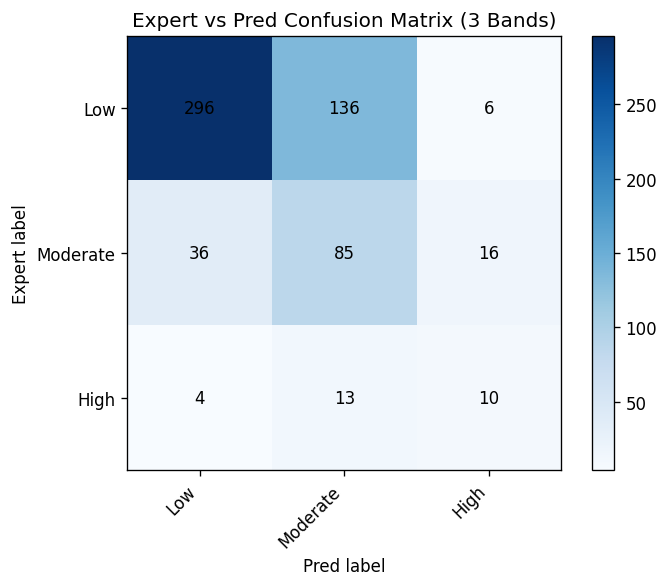

In [4]:
y_true = clean_df["expert_num"].to_numpy()
y_pred = clean_df["pred_num"].to_numpy()
label_numbers = list(LABEL_TO_NUM.values())

cm = confusion_matrix(y_true, y_pred, labels=label_numbers)
cm_df = pd.DataFrame(
    cm,
    index=[f"Expert {label}" for label in LABEL_ORDER],
    columns=[f"Pred {label}" for label in LABEL_ORDER],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
tick_positions = np.arange(len(LABEL_ORDER))
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(LABEL_ORDER, rotation=45, ha="right")
ax.set_yticklabels(LABEL_ORDER)
ax.set_xlabel("Pred label")
ax.set_ylabel("Expert label")
ax.set_title(f"Expert vs Pred Confusion Matrix ({BAND_COUNT} Bands)")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Metric 2: Per-Class Metrics

In [5]:
class_metrics_df = affinity_metrics.build_affinity_class_metrics(
    y_true,
    y_pred,
    labels=list(LABEL_TO_NUM.values()),
    class_names=LABEL_ORDER,
)

display(
    class_metrics_df[[
        'Class',
        'Support',
        'Precision',
        'Recall',
        'One_vs_Rest_Accuracy',
    ]]
)

,Class,Support,Precision,Recall,One_vs_Rest_Accuracy
0,Low,438,0.880952,0.675799,0.697674
1,Moderate,137,0.363248,0.620438,0.666113
2,High,27,0.312500,0.370370,0.935216


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [6]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))

print(f'Quadratic Weighted Kappa = {qwk:.4f}')
print(f'Mean signed error        = {mean_signed_error:.4f}')

Quadratic Weighted Kappa = 0.4233
Mean signed error        = 0.1777


## Metric 5: Reliability Curve

/tmp/ipykernel_40526/1501157577.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({
/tmp/ipykernel_40526/1501157577.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


,agreement_strength,n_cases,accuracy
0,0.333333,31.0,0.419355
1,0.500000,320.0,0.590088
2,1.000000,251.0,0.877557


,agreement_strength,expert_level,n_cases,accuracy
2,0.500000,High,22.0,0.363636
5,1.000000,High,5.0,0.400000
0,0.333333,Low,18.0,0.000000
3,0.500000,Low,203.0,0.458128
6,1.000000,Low,217.0,0.935484
1,0.333333,Moderate,13.0,1.000000
4,0.500000,Moderate,95.0,0.642105
7,1.000000,Moderate,29.0,0.379310


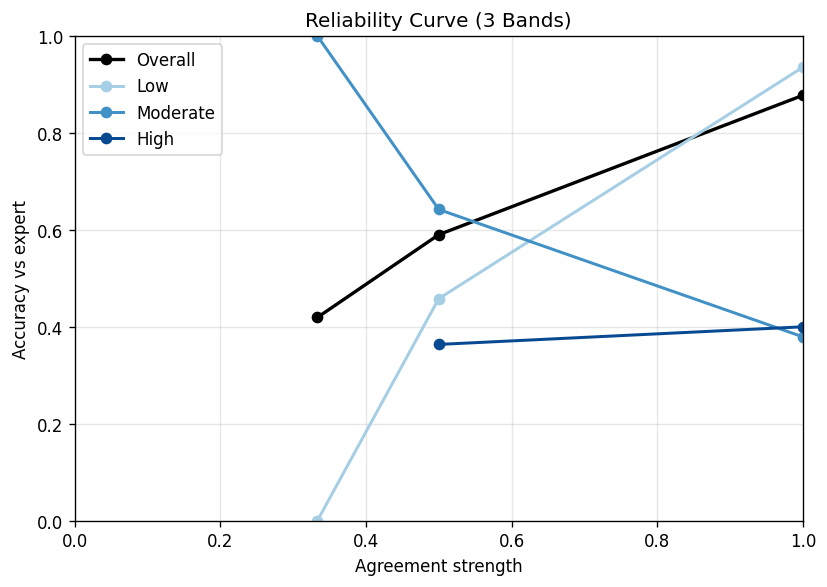

In [7]:
reliability_df = None
reliability_by_level_df = True


def compute_agreement_strength(row, pred_col_name, vote_cols):
    final_label = normalize_level(row[pred_col_name])
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(normalize_level)
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0 or pd.isna(final_label):
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))


def groupwise_one_vs_rest_accuracy(group_df):
    return affinity_metrics.aggregate_one_vs_rest_accuracy(
        group_df['expert_num'],
        group_df['pred_num'],
        labels=list(LABEL_TO_NUM.values()),
        class_names=LABEL_ORDER,
    )

if agreement_strength_col is not None and agreement_strength_col in clean_df.columns:
    work = clean_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in clean_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = clean_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=("pred_level", panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['agreement_strength'] = rel['agreement_strength'].astype(float)
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        reliability_df = (
            rel.groupby('agreement_strength', observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': groupwise_one_vs_rest_accuracy(group),
            }))
            .reset_index()
            .sort_values('agreement_strength')
        )

        reliability_by_level_df = (
            rel.groupby(['agreement_strength', 'expert_level'], observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': groupwise_one_vs_rest_accuracy(group),
            }))
            .reset_index()
            .sort_values(['expert_level', 'agreement_strength'])
        )

        display(reliability_df[['agreement_strength', 'n_cases', 'accuracy']])
        display(reliability_by_level_df[['agreement_strength', 'expert_level', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(
            reliability_df['agreement_strength'],
            reliability_df['accuracy'],
            marker='o',
            color='black',
            linewidth=2,
            label='Overall',
        )

        level_colors = dict(zip(LABEL_ORDER, plt.get_cmap('Blues')(np.linspace(0.35, 0.9, len(LABEL_ORDER)))))
        for level in LABEL_ORDER:
            level_df = reliability_by_level_df[reliability_by_level_df['expert_level'] == level]
            if level_df.empty:
                continue
            ax.plot(
                level_df['agreement_strength'],
                level_df['accuracy'],
                marker='o',
                linewidth=1.8,
                label=level,
                color=level_colors[level],
            )

        ax.set_xlabel('Agreement strength')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title(f'Reliability Curve ({BAND_COUNT} Bands)')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

In [8]:
clean_df

,Abstract_Index,Document Title_expert,RA2025_ID,RA_Question_expert,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_expert,Source_Type_expert,...,Final_Reason,Final_Method,Model_Slug,Cosine_x100_Mean,Run_ID_pred,Source_Type_pred,expert_level,pred_level,expert_num,pred_num
0,10.1109/TPWRS.2023.3256642,Sparse Measurement-Based Modelling Low-Order D...,28,What system services are needed across differe...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,10.8272,20260726_134607_5,pred,Low,Low,0,0
1,10.1109/TPWRS.2023.3256642,Sparse Measurement-Based Modelling Low-Order D...,29,What are the needs of a power system expressed...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,28.7700,20260726_134607_5,pred,Low,Low,0,0
2,10.1109/TPWRS.2023.3256642,Sparse Measurement-Based Modelling Low-Order D...,30,How can system performance requirements be tra...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,14.1707,20260726_134607_5,pred,Low,Low,0,0
3,10.1109/TPWRS.2023.3256642,Sparse Measurement-Based Modelling Low-Order D...,31,"For each service, how feasible is it to provid...",10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,3.7987,20260726_134607_5,pred,Low,Low,0,0
4,10.1109/TPWRS.2023.3256642,Sparse Measurement-Based Modelling Low-Order D...,32,How should system restoration services be stru...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,30.8376,20260726_134607_5,pred,Low,Low,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,10.1109/TPWRS.2023.3329820,A Spatio-Temporal Decomposition Method for the...,13,How can system operators quantify the bulk-lev...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,44.4465,20260726_134607_5,pred,Low,Moderate,0,1
598,10.1109/TPWRS.2023.3329820,A Spatio-Temporal Decomposition Method for the...,14,How can bulk-level services provided by DER be...,10,Low,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,22.8244,20260726_134607_5,pred,Low,Low,0,0
599,10.1109/TPWRS.2023.3334995,"Semi-Supervised, Non-Intrusive Disaggregation ...",12,What mechanisms and appropriate aggregate DER ...,70,Moderate,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,33.6745,20260726_134607_5,pred,Moderate,Moderate,1,1
600,10.1109/TPWRS.2023.3334995,"Semi-Supervised, Non-Intrusive Disaggregation ...",13,How can system operators quantify the bulk-lev...,70,Moderate,NaN,Abstracts Evaluation Template - Mark OM.xlsm,20260728_abstracts_evaluation_template_mark_om_v1,expert,...,NaN,ensemble_mean,NaN,46.6053,20260726_134607_5,pred,Moderate,Moderate,1,1


## Adjudication impact: pre- vs post-judge classification

This section compares the label that would have been assigned from the pre-adjudication score (`Affinity_Mean`) against the adjudicated label (`pred_level`) and the expert bucket.

Pairs are also split by `Final_Method`: for pairs resolved as `ensemble_mean`, `Final_Affinity` equals `Affinity_Mean` by construction, so pre/post are identical and would dilute the judge's real effect if left mixed into the headline numbers. The "adjudicated only" rows below isolate the pairs actually sent to the LLM judge.


In [9]:
# Create pre-adjudication bucket from the raw mean score
if 'Affinity_Mean' in clean_df.columns:
    clean_df['prejudge_level'] = clean_df['Affinity_Mean'].apply(normalize_level)
    clean_df['prejudge_num'] = clean_df['prejudge_level'].map(LABEL_TO_NUM).astype(int)
else:
    clean_df['prejudge_level'] = np.nan
    clean_df['prejudge_num'] = np.nan

# Compare each approach to the expert bucket
compare_df = clean_df.dropna(subset=['prejudge_level', 'pred_level', 'expert_level']).copy()
compare_df['prejudge_matches_expert'] = (compare_df['prejudge_num'] == compare_df['expert_num']).astype(int)
compare_df['pred_matches_expert'] = (compare_df['pred_num'] == compare_df['expert_num']).astype(int)
compare_df['judge_helped'] = compare_df['pred_matches_expert'] - compare_df['prejudge_matches_expert']

# Pairs where Final_Affinity == Affinity_Mean (Final_Method == 'ensemble_mean') never reached the
# judge, so prejudge_level == pred_level for them by construction. Mixing them into the headline
# accuracy/judge_helped numbers dilutes the judge's real effect. Split by Final_Method so the
# "did adjudication help" question is answered on the pairs it actually touched.
was_adjudicated = compare_df['Final_Method'] == 'adjudicated_llm'

print('=== All compared pairs (overall pipeline impact) ===')
print('Pre-adjudication accuracy vs expert:', compare_df['prejudge_matches_expert'].mean())
print('Adjudicated accuracy vs expert:', compare_df['pred_matches_expert'].mean())
print('Improved by adjudication:', (compare_df['judge_helped'] > 0).mean())
print('Worsened by adjudication:', (compare_df['judge_helped'] < 0).mean())
print('Unchanged by adjudication:', (compare_df['judge_helped'] == 0).mean())

print()
print('=== Only pairs actually sent to the LLM judge (Final_Method == adjudicated_llm) ===')
adjudicated_df = compare_df[was_adjudicated]
print('N cases:', len(adjudicated_df))
print('Pre-adjudication accuracy vs expert:', adjudicated_df['prejudge_matches_expert'].mean())
print('Adjudicated accuracy vs expert:', adjudicated_df['pred_matches_expert'].mean())
print('Improved by adjudication:', (adjudicated_df['judge_helped'] > 0).mean())
print('Worsened by adjudication:', (adjudicated_df['judge_helped'] < 0).mean())
print('Unchanged by adjudication:', (adjudicated_df['judge_helped'] == 0).mean())

print()
print('=== Untouched pairs (Final_Method == ensemble_mean, sanity check - delta should be 0) ===')
untouched_df = compare_df[~was_adjudicated]
print('N cases:', len(untouched_df))
print('Pre-adjudication accuracy vs expert:', untouched_df['prejudge_matches_expert'].mean())
print('Adjudicated accuracy vs expert:', untouched_df['pred_matches_expert'].mean())

summary_df = pd.DataFrame({
    'Population': ['All pairs', 'All pairs', 'Adjudicated only', 'Adjudicated only', 'Untouched only', 'Untouched only'],
    'Approach': ['Pre-adjudication', 'Adjudicated', 'Pre-adjudication', 'Adjudicated', 'Pre-adjudication', 'Adjudicated'],
    'Accuracy_vs_expert': [
        compare_df['prejudge_matches_expert'].mean(), compare_df['pred_matches_expert'].mean(),
        adjudicated_df['prejudge_matches_expert'].mean(), adjudicated_df['pred_matches_expert'].mean(),
        untouched_df['prejudge_matches_expert'].mean(), untouched_df['pred_matches_expert'].mean(),
    ],
    'N_cases': [len(compare_df), len(compare_df), len(adjudicated_df), len(adjudicated_df), len(untouched_df), len(untouched_df)],
})

display(summary_df)

# Confusion-style table for pre-adjudication vs expert (adjudicated-only population, since the
# untouched pairs contribute an identical pre/post confusion matrix and add no information here)
label_numbers = list(LABEL_TO_NUM.values())
pre_confusion = confusion_matrix(
    adjudicated_df['expert_num'],
    adjudicated_df['prejudge_num'],
    labels=label_numbers,
)
pre_confusion_df = pd.DataFrame(
    pre_confusion,
    index=[f"Expert {label}" for label in LABEL_ORDER],
    columns=[f"Pre {label}" for label in LABEL_ORDER],
)

pred_confusion = confusion_matrix(
    adjudicated_df['expert_num'],
    adjudicated_df['pred_num'],
    labels=label_numbers,
)
pred_confusion_df = pd.DataFrame(
    pred_confusion,
    index=[f"Expert {label}" for label in LABEL_ORDER],
    columns=[f"Pred {label}" for label in LABEL_ORDER],
)

print('Pre-adjudication vs expert confusion matrix (adjudicated-only pairs):')
display(pre_confusion_df)

print('Adjudicated vs expert confusion matrix (adjudicated-only pairs):')
display(pred_confusion_df)

# Show cases where adjudication improved the classification
improved = adjudicated_df[adjudicated_df['judge_helped'] > 0][['Abstract_Index', 'RA2025_ID', 'expert_level', 'prejudge_level', 'pred_level']]
if not improved.empty:
    display(improved.head(20))
else:
    print('No cases improved by adjudication in the current comparison.')

# Show cases where adjudication worsened the classification
worsened = adjudicated_df[adjudicated_df['judge_helped'] < 0][['Abstract_Index', 'RA2025_ID', 'expert_level', 'prejudge_level', 'pred_level']]
if not worsened.empty:
    display(worsened.head(20))
else:
    print('No cases worsened by adjudication in the current comparison.')

=== All compared pairs (overall pipeline impact) ===
Pre-adjudication accuracy vs expert: 0.6495016611295681
Adjudicated accuracy vs expert: 0.6495016611295681
Improved by adjudication: 0.0
Worsened by adjudication: 0.0
Unchanged by adjudication: 1.0

=== Only pairs actually sent to the LLM judge (Final_Method == adjudicated_llm) ===
N cases: 0
Pre-adjudication accuracy vs expert: nan
Adjudicated accuracy vs expert: nan
Improved by adjudication: nan
Worsened by adjudication: nan
Unchanged by adjudication: nan

=== Untouched pairs (Final_Method == ensemble_mean, sanity check - delta should be 0) ===
N cases: 602
Pre-adjudication accuracy vs expert: 0.6495016611295681
Adjudicated accuracy vs expert: 0.6495016611295681


,Population,Approach,Accuracy_vs_expert,N_cases
0,All pairs,Pre-adjudication,0.649502,602
1,All pairs,Adjudicated,0.649502,602
2,Adjudicated only,Pre-adjudication,NaN,0
3,Adjudicated only,Adjudicated,NaN,0
4,Untouched only,Pre-adjudication,0.649502,602
5,Untouched only,Adjudicated,0.649502,602


Pre-adjudication vs expert confusion matrix (adjudicated-only pairs):


,Pre Low,Pre Moderate,Pre High
Expert Low,0,0,0
Expert Moderate,0,0,0
Expert High,0,0,0


Adjudicated vs expert confusion matrix (adjudicated-only pairs):


,Pred Low,Pred Moderate,Pred High
Expert Low,0,0,0
Expert Moderate,0,0,0
Expert High,0,0,0


No cases improved by adjudication in the current comparison.
No cases worsened by adjudication in the current comparison.


## Optional: Cluster Bootstrap Confidence Intervals

Bootstrap resamples complete abstracts (clusters), not individual rows.

Set `RUN_BOOTSTRAP = True` in the cell below to run this section.

In [10]:
from sklearn.metrics import recall_score

RUN_BOOTSTRAP = True
N_BOOT = 500
BOOTSTRAP_SEED = 42

bootstrap_summary = None

if RUN_BOOTSTRAP:
    if "Abstract_Index" not in clean_df.columns:
        print("Bootstrap skipped: Abstract_Index is missing.")
    else:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
        abstract_ids = pd.Series(clean_df["Abstract_Index"].dropna().unique())

        if len(abstract_ids) == 0:
            print("Bootstrap skipped: no abstract IDs available.")
        else:
            label_numbers = list(LABEL_TO_NUM.values())
            y_true = clean_df["expert_num"].to_numpy()
            y_pred = clean_df["pred_num"].to_numpy()
            recalls = recall_score(y_true, y_pred, labels=label_numbers, average=None, zero_division=0)

            qwk_samples = []
            mse_samples = []
            recall_samples = []

            for _ in range(N_BOOT):
                sampled_ids = rng.choice(abstract_ids.to_numpy(), size=len(abstract_ids), replace=True)
                sampled_parts = [clean_df[clean_df["Abstract_Index"] == aid] for aid in sampled_ids]
                boot_df = pd.concat(sampled_parts, ignore_index=True)

                y_t = boot_df["expert_num"].to_numpy()
                y_p = boot_df["pred_num"].to_numpy()

                qwk_samples.append(cohen_kappa_score(y_t, y_p, weights="quadratic"))
                mse_samples.append(float(np.mean(y_p - y_t)))
                recall_samples.append(recall_score(y_t, y_p, labels=label_numbers, average=None, zero_division=0))

            recall_arr = np.vstack(recall_samples)

            def ci(values, alpha=0.05):
                lo = np.nanpercentile(values, 100 * (alpha / 2))
                hi = np.nanpercentile(values, 100 * (1 - alpha / 2))
                return float(lo), float(hi)

            qwk_ci = ci(np.array(qwk_samples))
            mse_ci = ci(np.array(mse_samples))
            recall_cis = [ci(recall_arr[:, index]) for index in range(len(LABEL_ORDER))]

            bootstrap_summary = pd.DataFrame([
                {"Metric": "Quadratic Weighted Kappa", "CI_2.5%": qwk_ci[0], "CI_97.5%": qwk_ci[1]},
                *[
                    {"Metric": f"Recall {label}", "CI_2.5%": recall_ci[0], "CI_97.5%": recall_ci[1]}
                    for label, recall_ci in zip(LABEL_ORDER, recall_cis)
                ],
                {"Metric": "Mean Signed Error", "CI_2.5%": mse_ci[0], "CI_97.5%": mse_ci[1]},
            ])
            display(bootstrap_summary)
else:
    print("Bootstrap disabled (RUN_BOOTSTRAP = False).")

,Metric,CI_2.5%,CI_97.5%
0,Quadratic Weighted Kappa,0.351419,0.493689
1,Recall Low,0.610553,0.735933
2,Recall Moderate,0.543456,0.702288
3,Recall High,0.200000,0.568478
4,Mean Signed Error,0.109102,0.246684
